In [1]:
import torch
import FasterRCNN
from dataset import TensorToImg, Coco

In [2]:
dataset = Coco("/home/wanderer2414/coco2017/")

loading annotations into memory...
Done (t=8.50s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [5]:
model = FasterRCNN.Model(device=torch.device("cpu"))

In [6]:
model.train(dataset, FasterRCNN.faster_rcnn_loss)

[00:00:26] Proposal: 3000 Loss: 939.7850341796875 ██████████████████████████████████████████████████ 8        /        8
[00:00:26] Done                           ██████████████████████████████████████████████████████████ 8        /        8


In [7]:
model = FasterRCNN.FasterRCNN(device=torch.device("cpu"))
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [8]:
# model = FasterRCNN.FasterRCNN(device=torch.device("cpu"))
x = dataset.getTrainTensor(5)
score:torch.Tensor = model(x)

tensor([ 1.,  0., 10., 19., 11., 19.], grad_fn=<SliceBackward0>)
tensor(939.7850, grad_fn=<AddBackward0>)


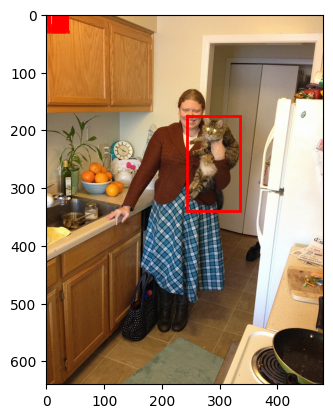

In [9]:
import matplotlib.pyplot as plt
from matplotlib import patches
from torch import topk
plt.imshow(TensorToImg(x))
print(score[0][0][:6])
for scr in score[0]:
    x1, y1, x2, y2 = scr[2:6].detach().numpy()
    value, indices = topk(scr, k=10)
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
    plt.subplot().add_patch(rect)

x1, y1, x2, y2 = dataset.getTrainLabel(5)[0][:4].detach().numpy()
rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
lss = FasterRCNN.faster_rcnn_loss(score, dataset.getTrainLabel(5).unsqueeze(0))
print(lss)
plt.subplot().add_patch(rect)
plt.show()